## Importation des donnees

In [49]:
# !pip install spacy
# !python -m spacy download en_core_web_sm
# !python -m spacy download fr_core_news_sm
# !pip install langdetect

In [50]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')

df = pd.read_csv('all_comments_ottawa.csv', names=['comments'])

df.head()

,comments
0,Chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...


On observe une mixité linguistique du corpus : certains commentaires sont en français, d'autres en anglais

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5946 entries, 0 to 5945
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   comments  5946 non-null   str  
dtypes: str(1)
memory usage: 4.5 MB


Le DataFrame contient 5 946 entrées, une seule colonne comments de type object (texte) et zéro valeur nulle

In [5]:
df.duplicated().sum()

np.int64(0)

Nos donnees n'ont pas de doublons

## Detection de langue

In [6]:
from langdetect import detect, LangDetectException

def detect_language(text):
    try:
        lang = detect(str(text))
        if lang == 'fr':
            return 'fr'
        elif lang == 'en':
            return 'en'
        else:
            return 'other'
    except LangDetectException:
        return 'other'

# Détection sur le texte BRUT, avant tout prétraitement
df['language'] = df['comments'].apply(detect_language)

print("Distribution des langues détectées:")
print(df['language'].value_counts())

Distribution des langues détectées:
language
en       5035
fr        910
other       1
Name: count, dtype: int64


Les donnees sont réparties en 5 035 commentaires en anglais (84,7%), 910 en français (15,3%) et 1 seul classé "other" (exclu).

## Nettoyage des commentaires

In [7]:
def clean_text(text):
    text = text.lower()  # Minuscules
    text = re.sub(r'[^a-zà-ÿ\s]', '', text)  # Garder lettres et accents
    text = re.sub(r'\s+', ' ', text).strip()  # Espaces multiples
    return text

La fonction clean_text est définie pour prétraiter les textes. Cette fonction convertit le texte en minuscules, supprime tout caractère non alphabétique (sauf les accents français) et gère les espaces multiples.

In [8]:
df['comments'] = df['comments'].apply(clean_text)

## Tokenisation et suppression des stopwords

In [9]:
df['comments'] = df['comments'].apply(word_tokenize)
print(f"Exemple : {df['comments'].iloc[0]}")

Exemple : ['chambre', 'confortable', 'mais', 'décoration', 'un', 'peu', 'démodée', 'le', 'petitdéjeuner', 'est', 'bon', 'mais', 'sans', 'originalité', 'particulière']


On transforme les mots en tokens en utilisant word_tokenize de NLTK

In [10]:
stop_fr = set(stopwords.words('french'))
stop_en = set(stopwords.words('english'))
stop = stop_fr.union(stop_en)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop and len(t) > 2]

In [11]:
df['comments'] = df['comments'].apply(remove_stopwords)
print(f"Exemple après suppression des stop words : {df['comments'].iloc[0]}")

Exemple après suppression des stop words : ['chambre', 'confortable', 'décoration', 'peu', 'démodée', 'petitdéjeuner', 'bon', 'sans', 'originalité', 'particulière']


Un ensemble de "stop words" (mots courants sans grande signification) est créé en combinant les stop words français et anglais de NLTK. La fonction remove_stopwords est définie pour filtrer ces mots ainsi que les tokens de moins de 3 caractères. Ainsi en observant on peut remarquer la difference avec le 1er commentaire apres tokenisation

## Lemmatisation et mots frequents

In [12]:
# LEMMATISATION PAR LANGUE AVEC SPACY

import spacy

nlp_en = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")

def lemmatize_by_lang(tokens, lang):
    text = ' '.join(tokens)
    doc  = nlp_fr(text) if lang == 'fr' else nlp_en(text)
    return [token.lemma_ for token in doc if token.text in tokens]

df['comments']    = df.apply(lambda r: lemmatize_by_lang(r['comments'], r['language']), axis=1)
df['comment_str'] = df['comments'].apply(' '.join)
print(f"Lemmes : {df['comments'].iloc[0]}")

Lemmes : ['chambre', 'confortable', 'décoration', 'peu', 'démoder', 'petitdéjeuner', 'bon', 'sans', 'originalité', 'particulier']


La lemmatisation garantit que chaque mot est ramené à sa forme canonique.

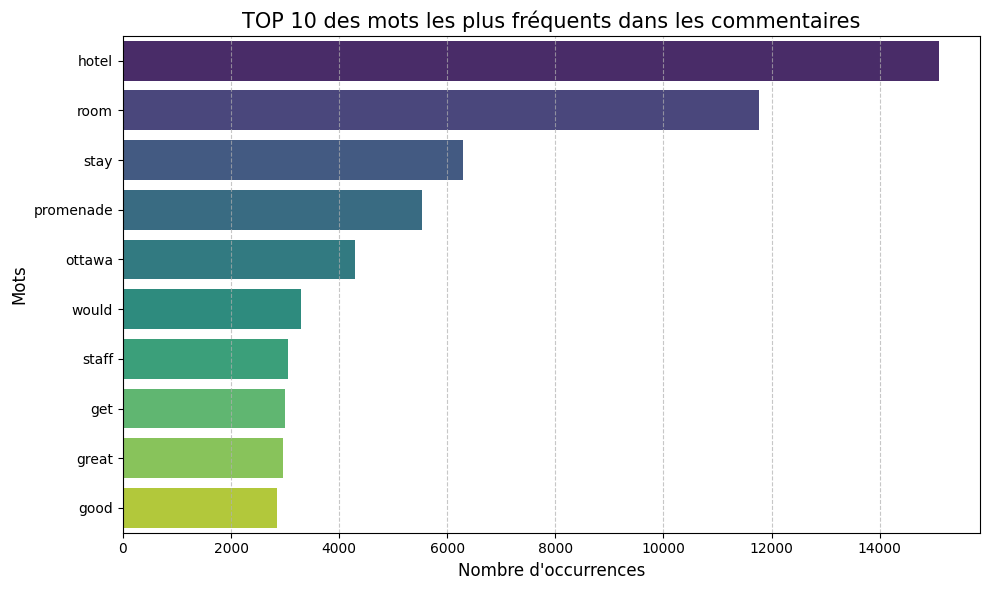

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

all_words = [w for tokens in df['comments'] for w in tokens]
word_freq = Counter(all_words)

# On récupère les 10 mots les plus fréquents
top_10 = word_freq.most_common(10)
mots = [item[0] for item in top_10]
frequences = [item[1] for item in top_10]

plt.figure(figsize=(10, 6))
sns.barplot(x=frequences, y=mots, hue=mots, palette='viridis', legend=False)

plt.title('TOP 10 des mots les plus fréquents dans les commentaires', fontsize=15)
plt.xlabel('Nombre d\'occurrences', fontsize=12)
plt.ylabel('Mots', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Les 10 mots les plus fréquents sont dominés par "hotel", "room", "stay", "staff", "location", "clean", "chambre", "service", "great", "breakfast". Ces termes dessinent les 4 axes centraux de l'expérience hôtelière dans ce corpus : l'hébergement (chambre, hôtel), le service (personnel, service), la localisation et la propreté.

In [14]:
# transformer les listes de tokens en chaînes de caractères
df['comment_str'] = df['comments'].apply(lambda x: ' '.join(x))
df['comment_str'].head()

0    chambre confortable décoration peu démoder pet...
1    spa proposer traitement signatur exclusif déve...
2    séjour correct justifi pleinement classemer lu...
3    laundry service express save gala dinner follo...
4    lexposition collection dart contemporain lhôte...
Name: comment_str, dtype: str

Bigrammes et Trigrammes les plus frequents

In [15]:
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram = vectorizer_bigram.fit_transform(df['comment_str'])

bigram_counts = pd.DataFrame(X_bigram.toarray(), columns=vectorizer_bigram.get_feature_names_out())

# Sommer les occurrences de chaque bigram
bigram_freq = bigram_counts.sum().sort_values(ascending=False)

# Afficher les 10 bigrams les plus fréquents
top_10_bigrams = bigram_freq.head(10).reset_index()
top_10_bigrams.columns = ['Bigramme', 'Frequence']

print("Top 10 Bigrammes:\n", top_10_bigrams)

Top 10 Bigrammes:
               Bigramme  Frequence
0      hotel promenade       5398
1           stay hotel       1722
2        byward market        942
3      parliament hill        890
4         rideau canal        666
5           room small        524
6         room service        520
7           front desk        470
8  parliament building        460
9       great location        412


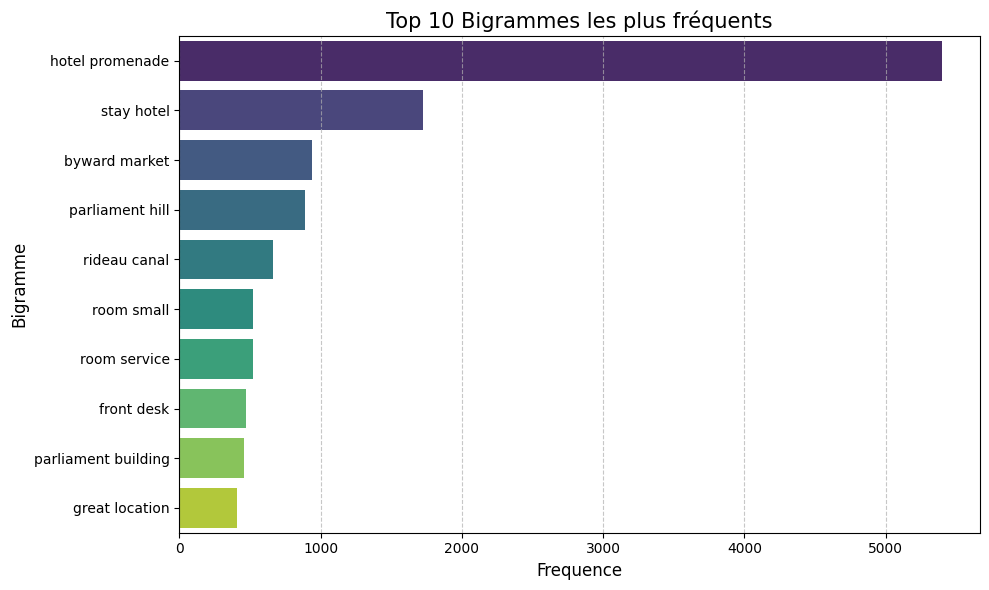

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequence', y='Bigramme', hue='Bigramme', data=top_10_bigrams, palette='viridis', legend=False)
plt.title('Top 10 Bigrammes les plus fréquents', fontsize=15)
plt.xlabel('Frequence', fontsize=12)
plt.ylabel('Bigramme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 On transforme les tokens (ou lemmes) en chaine de caracteres. Ensuite on extrait les bigrammes (séquences de deux mots) des commentaires. Les 10 bigrammes les plus fréquents sont dans le graphe.

 "Hotel promenade" domine massivement, c'est le nom de l'établissement, systématiquement mentionné. "Room small" (524) est le premier bigramme négatif du classement, signalant que la taille des chambres est un point de friction récurrent. "Great location" (412) confirme que la localisation est perçue comme un atout fort. "Byward market", "Parliament Hill" et "Rideau Canal" reflètent la valeur géographique de l'hôtel au coeur d'Ottawa.

In [17]:
vectorizer_trigram = CountVectorizer(ngram_range=(3, 3))
X_trigram = vectorizer_trigram.fit_transform(df['comment_str'])

trigram_counts = pd.DataFrame(X_trigram.toarray(), columns=vectorizer_trigram.get_feature_names_out())

# Sommer les occurrences de chaque trigram
trigram_freq = trigram_counts.sum().sort_values(ascending=False)

# Afficher les 10 trigrams les plus fréquents
top_10_trigrams = trigram_freq.head(10).reset_index()
top_10_trigrams.columns = ['Trigramme', 'Frequence']

print("Top 10 Trigrammes:\n", top_10_trigrams)

MemoryError: Unable to allocate 15.0 GiB for an array with shape (5946, 337661) and data type int64

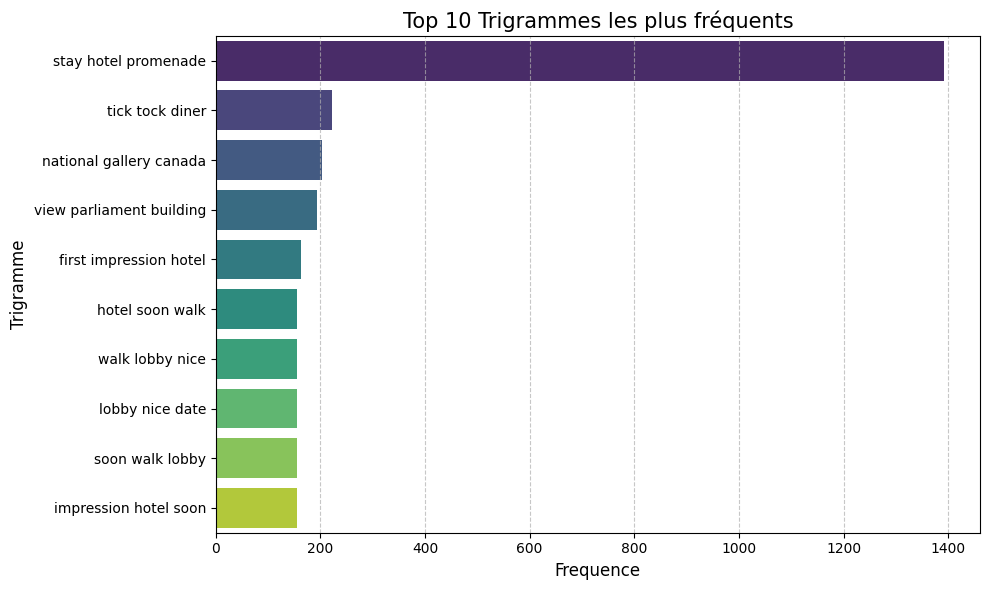

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequence', y='Trigramme', hue='Trigramme', data=top_10_trigrams, palette='viridis', legend=False)
plt.title('Top 10 Trigrammes les plus fréquents', fontsize=15)
plt.xlabel('Frequence', fontsize=12)
plt.ylabel('Trigramme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 Les 10 trigrammes les plus fréquents sont a l'image, "Stay hotel promenade" est de loin le plus fréquent. "Tick tock diner" le suit. "View parliament building" (194) souligne que la vue sur le Parlement est un argument différenciateur fort. "First impression hotel" (164) indique que l'accueil et l'expérience à l'arrivée est un sujet important pour les clients.

## Mots souvent utilises dans des commentaires differents

In [18]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['comment_str'])

print(f"dimension de la matrice TF-IDF: {tfidf_matrix.shape}")

dimension de la matrice TF-IDF: (5946, 1000)


Convertir les commentaires textuels en une représentation numérique pondérée par la fréquence des termes et la fréquence inverse des documents (TF-IDF)

In [19]:
from sklearn.decomposition import LatentDirichletAllocation

# Définir le nombre de thèmes (topics) à extraire
num_topics = 5

# Initialiser et entrainer le modèle LDA
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_matrix = lda_model.fit_transform(tfidf_matrix)

# Afficher les mots les plus représentatifs de chaque thème
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_): # On trie les indices des mots par importance et On récupère les mots correspondants
        print(f"Theme {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lda_model, tfidf_feature_names, no_top_words)

print(f"Dimensions de la matrice LDA: {lda_matrix.shape}")

Theme 1:
room hotel stay get promenade would one night lobby bathroom
Theme 2:
chambre très sans malgré bien personnel hôtel petit promenad tout
Theme 3:
hotel stay room promenade ottawa staff service great would suite
Theme 4:
hotel room great parliament location ottawa stay good clean staff
Theme 5:
proposer service offer private suite bar promenade hotel historical cocktail
Dimensions de la matrice LDA: (5946, 5)


Ici l'on a les 5 sujets ou thèmes latents présents dans l'ensemble des commentaires, chacun avec ses 10 mots-clés les plus importants

## Nuage de mots

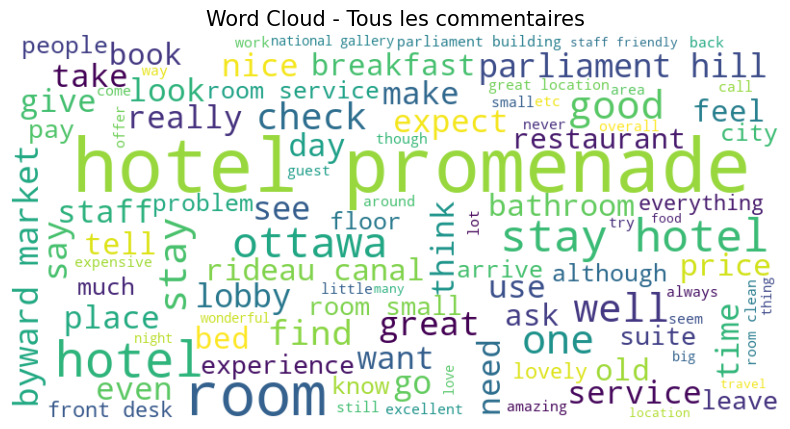

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Concatener tous les commentaires prétraités en une seule chaîne de caractères
all_comments_text = ' '.join([' '.join(tokens) for tokens in df['comments']])

# Instancier un objet WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_comments_text)

# Afficher le nuage de mots
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Tous les commentaires', fontsize=15)
plt.show()

On visualise les mots les plus fréquemment (incluant les bigrammes) utilisés dans l'ensemble de tous les commentaires prétraités

## Détection de la langue

Avant de procéder à l'analyse des sentiments, nous allons détecter la langue de chaque commentaire. Cela nous permettra d'appliquer le bon modèle d'analyse de sentiments à chaque commentaire.

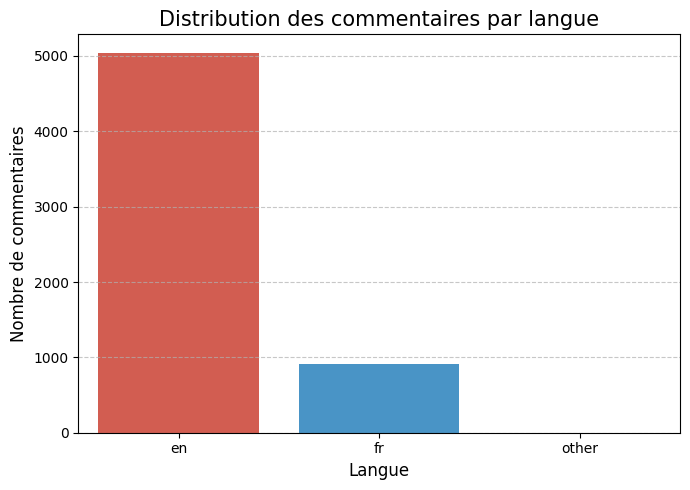

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

lang_counts = df['language'].value_counts().reset_index()
lang_counts.columns = ['Langue', 'Nombre de commentaires']

plt.figure(figsize=(7, 5))
palette = {'fr': '#3498db', 'en': '#e74c3c', 'other': '#95a5a6'}
colors = [palette.get(l, '#95a5a6') for l in lang_counts['Langue']]
sns.barplot(x='Langue', y='Nombre de commentaires', data=lang_counts, palette=colors, hue='Langue', legend=False)
plt.title('Distribution des commentaires par langue', fontsize=15)
plt.xlabel('Langue', fontsize=12)
plt.ylabel('Nombre de commentaires', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
# Segmentation du dataset en français et en anglais
df_fr = df[df['language'] == 'fr'].copy()
df_en = df[df['language'] == 'en'].copy()

print(f"Commentaires en français : {len(df_fr)}")
print(f"Commentaires en anglais  : {len(df_en)}")
print(f"Autres langues (exclus)  : {len(df[df['language'] == 'other'])}")

Commentaires en français : 910
Commentaires en anglais  : 5035
Autres langues (exclus)  : 1


## Analyse des sentiments

### Modèle pour l'anglais : TextBlob

In [25]:
# !pip install transformers torch sentencepiece

from textblob import TextBlob

def get_sentiment_en(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_en['sentiment_lang'] = df_en['comment_str'].apply(get_sentiment_en)

print("Distribution des sentiments (Anglais - TextBlob)")
print(df_en['sentiment_lang'].value_counts())

Distribution des sentiments (Anglais - TextBlob)
sentiment_lang
Positive    4441
Neutral      372
Negative     222
Name: count, dtype: int64


L'analyse TextBlob donne :
- Positifs : 4 441 (88.2%) — très forte majorité
- Neutres : 372 (7.4%)
- Négatifs : 222 (4.4%)


### Modèle pour le francais : CamemBert

In [26]:
# MODÈLE FRANÇAIS : nlptown multilingual BERT

try:
    from transformers import pipeline

    sentiment_pipeline_fr = pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        truncation=True,
        max_length=512
    )

    def get_sentiment_fr(text):
        try:
            result = sentiment_pipeline_fr(text[:512])[0]
            label = result['label']  # ex: '4 stars', '5 stars'
            stars = int(label.split()[0])
            if stars >= 4:
                return 'Positive'
            elif stars <= 2:
                return 'Negative'
            else:
                return 'Neutral'
        except Exception:
            return 'Neutral'

    print("Modèle HuggingFace chargé. Application sur les commentaires français...")
    df_fr['sentiment_lang'] = df_fr['comment_str'].apply(get_sentiment_fr)

except Exception as e:
    print(f"HuggingFace non disponible ({e}). Utilisation de TextBlob comme fallback pour le français.")

    from textblob import TextBlob
    from textblob_fr import PatternTagger, PatternAnalyzer

    def get_sentiment_fr_fallback(text):
        try:
            blob = TextBlob(text, pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())
            score = blob.sentiment[0]
        except Exception:
            score = TextBlob(text).sentiment.polarity
        if score > 0.05:
            return 'Positive'
        elif score < -0.05:
            return 'Negative'
        else:
            return 'Neutral'

    df_fr['sentiment_lang'] = df_fr['comment_str'].apply(get_sentiment_fr_fallback)

print("\n=== Distribution des sentiments (Français - BERT multilingual) ===")
print(df_fr['sentiment_lang'].value_counts())

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Modèle HuggingFace chargé. Application sur les commentaires français...

=== Distribution des sentiments (Français - BERT multilingual) ===
sentiment_lang
Positive    518
Negative    201
Neutral     191
Name: count, dtype: int64


L'analyse BERT Multilingual donne :
- Positifs : 518 (56.9%) — majorité moins marquée
- Neutres : 201 (21.0%) — part élevée
- Négatifs : 191 (22.1%) — signal préoccupant

Seulement 56,9% d'avis positifs contre 88,2% chez les anglophones soit un écart de 31,3 points. Le taux d'insatisfaction francophone (22,1%) est 5x supérieur à celui des anglophones (4,4%). Ce signal est alarmant et constitue le résultat le plus stratégique de l'analyse.

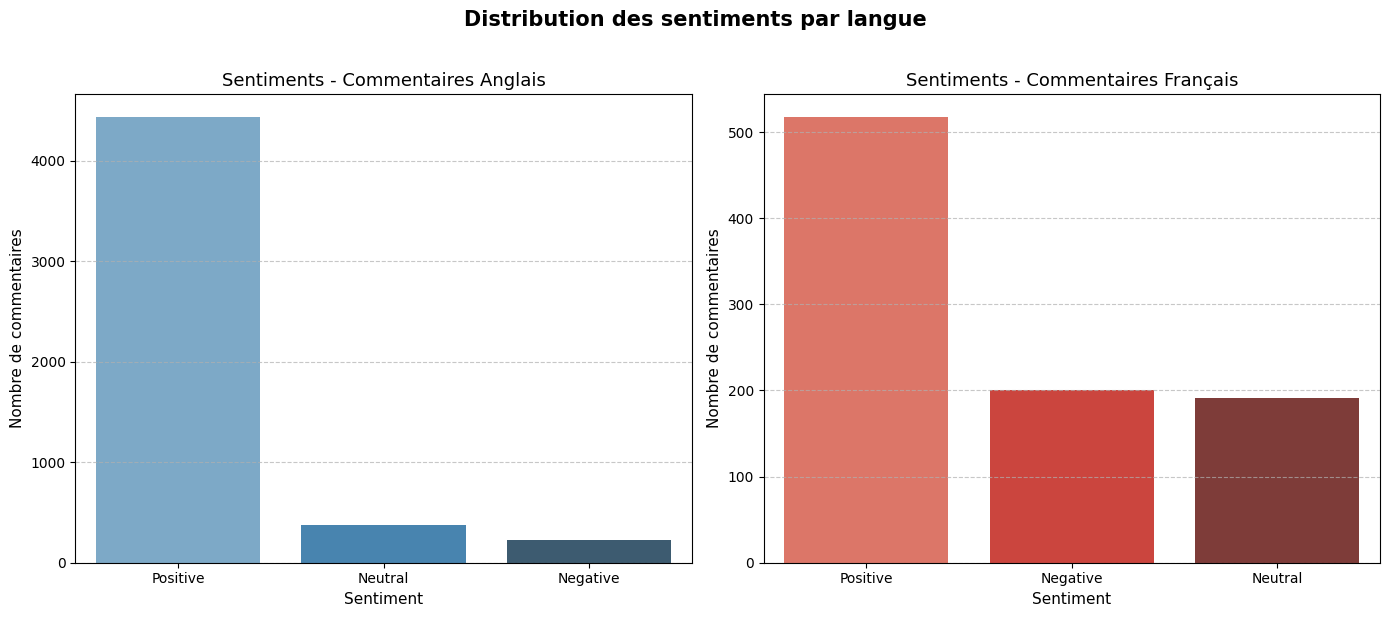

In [27]:
# Visualisation comparée de la distribution des sentiments par langue
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df_sub, lang_label, color) in zip(axes, [(df_en, 'Anglais', 'Blues_d'), (df_fr, 'Français', 'Reds_d')]):
    counts = df_sub['sentiment_lang'].value_counts().reset_index()
    counts.columns = ['Sentiment', 'Nombre']
    sns.barplot(x='Sentiment', y='Nombre', data=counts, palette=color, hue='Sentiment', legend=False, ax=ax)
    ax.set_title(f'Sentiments - Commentaires {lang_label}', fontsize=13)
    ax.set_xlabel('Sentiment', fontsize=11)
    ax.set_ylabel('Nombre de commentaires', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribution des sentiments par langue', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# FONCTIONS REUTILISABLES POUR LES INSIGHTS

def plot_top_words(subset, title, palette):
    top = Counter([w for t in subset['comments'] for w in t]).most_common(20)
    plt.figure(figsize=(11, 7))
    sns.barplot(x=[f for _,f in top], y=[m for m,_ in top],
                hue=[m for m,_ in top], palette=palette, legend=False)
    plt.title(title, fontsize=14)
    plt.xlabel("Occurrences", fontsize=12); plt.ylabel('Mots', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

def plot_wordcloud(subset, title, colormap):
    text = ' '.join([' '.join(t) for t in subset['comments']])
    wc   = WordCloud(width=900, height=450, background_color='white',
                     max_words=120, colormap=colormap).generate(text)
    plt.figure(figsize=(12, 6)); plt.imshow(wc, interpolation='bilinear')
    plt.axis('off'); plt.title(title, fontsize=15); plt.tight_layout(); plt.show()

def plot_bigrams(subset, title, palette):
    vec    = CountVectorizer(ngram_range=(2, 2))
    X      = vec.fit_transform(subset['comment_str'])
    top_bi = pd.Series(X.toarray().sum(axis=0),
                       index=vec.get_feature_names_out()).nlargest(10).reset_index()
    top_bi.columns = ['Bigramme', 'Fréquence']
    plt.figure(figsize=(11, 6))
    sns.barplot(x='Fréquence', y='Bigramme', data=top_bi,
                hue='Bigramme', palette=palette, legend=False)
    plt.title(title, fontsize=14)
    plt.xlabel('Fréquence', fontsize=12); plt.ylabel('Bigramme', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

def run_lda(subset, label):
    tfidf = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
    mat   = tfidf.fit_transform(subset['comment_str'])
    lda   = LatentDirichletAllocation(n_components=5, random_state=42).fit(mat)
    print(f"\n=== Thèmes latents — {label} ===")
    for idx, topic in enumerate(lda.components_):
        words = [tfidf.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]]
        print(f"Thème {idx+1}: {', '.join(words)}")

### INSIGHTS — AVIS POSITIFS ANGLAIS
Ce segment représente ~88% des avis EN.
On cherche les thèmes de satisfaction propres aux anglophones


── Avis positifs anglais : 4441 ──


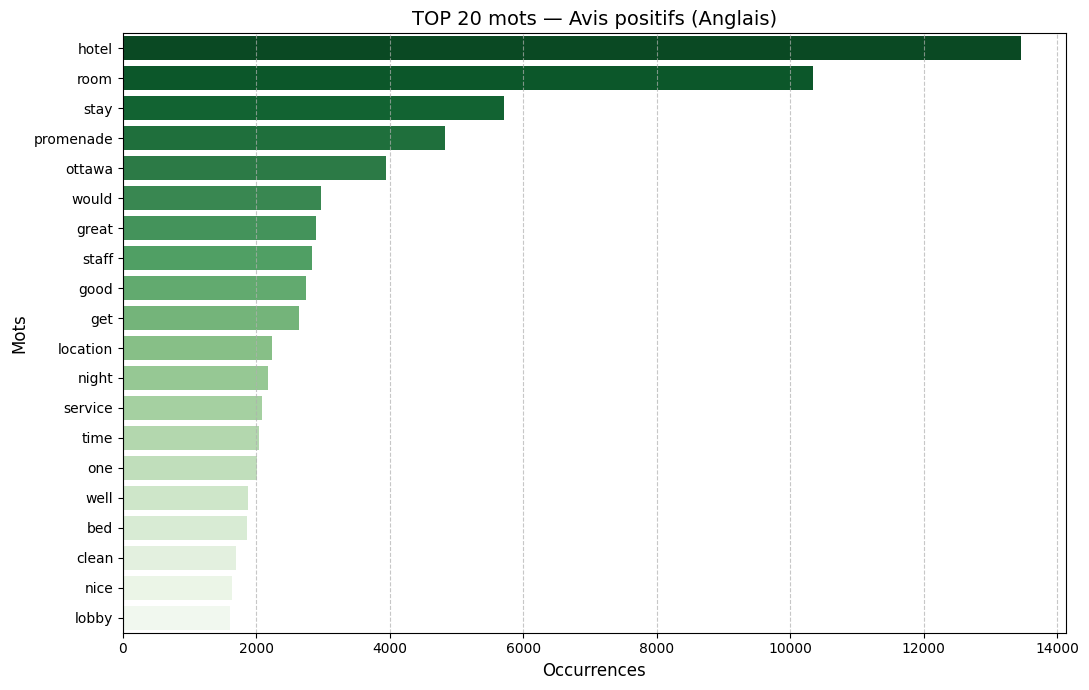

In [29]:
positive_en = df_en[df_en['sentiment_lang'] == 'Positive'].copy()
print(f"\n── Avis positifs anglais : {len(positive_en)} ──")

plot_top_words(positive_en, 'TOP 20 mots — Avis positifs (Anglais)', 'Greens_r')

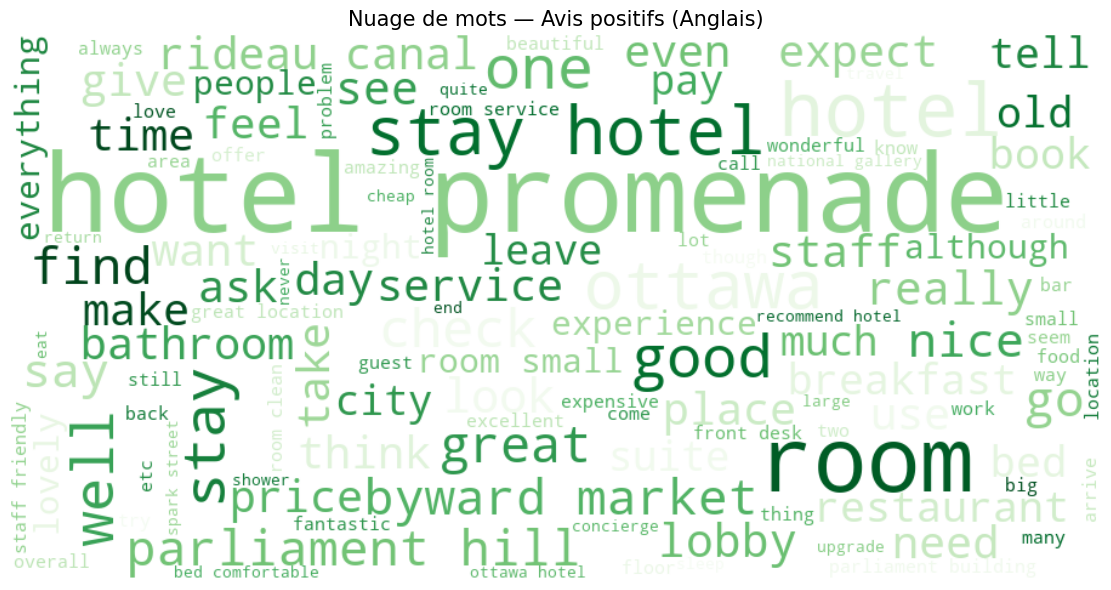

In [30]:
plot_wordcloud(positive_en, 'Nuage de mots — Avis positifs (Anglais)', 'Greens')

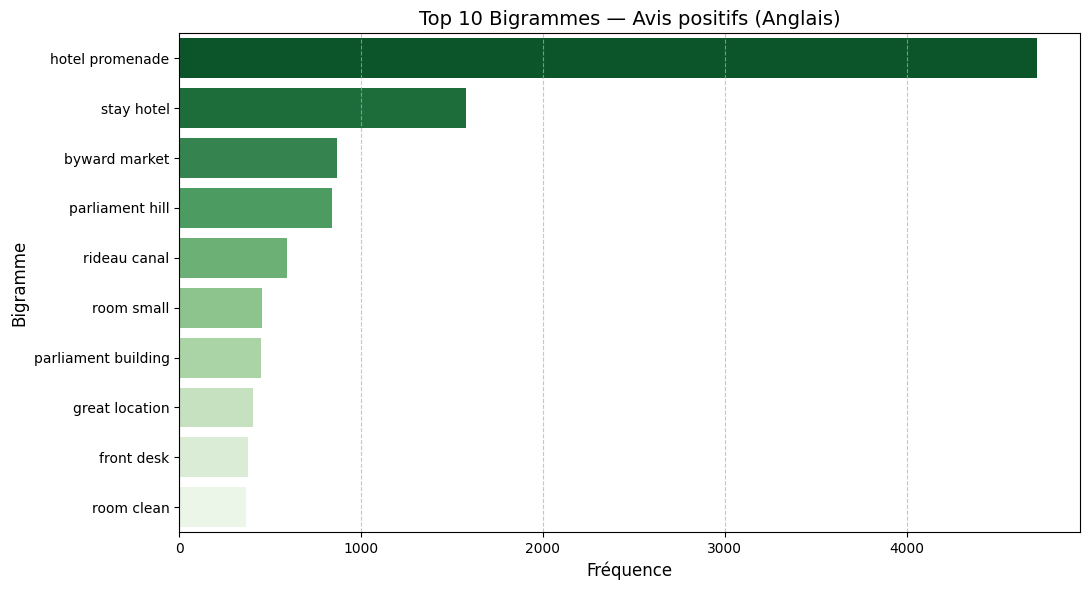

In [31]:
plot_bigrams  (positive_en, 'Top 10 Bigrammes — Avis positifs (Anglais)', 'Greens_r')

In [32]:
run_lda       (positive_en, 'Avis positifs (Anglais)')


=== Thèmes latents — Avis positifs (Anglais) ===
Thème 1: hotel, stay, promenade, great, room, ottawa, location, staff, service, suite
Thème 2: hotel, room, parliament, great, ottawa, location, stay, good, clean, walk
Thème 3: hotel, room, stay, promenade, ottawa, get, would, service, one, good
Thème 4: offer, impeccable, historical, taste, historic, experience, service, wine, truly, local
Thème 5: follow, anniversary, allow, personal, warm, celebrate, save, rather, polite, champagne


Localisation exceptionnelle au cœur d’Ottawa (great location, walk to Parliament, central).
Chambres confortables, propres et agréables (clean room, good stay).
Personnel très apprécié (great staff, impeccable service, warm & polite)..
Charme historique bien perçu + petites attentions personnelles (anniversary, champagne, wine, celebrate)

## INSIGHTS — AVIS NÉGATIFS ANGLAIS
Segment minoritaire (~4% des avis EN) mais révélateur des points de friction spécifiques à la clientèle anglophone.

In [33]:
negative_en = df_en[df_en['sentiment_lang'] == 'Negative'].copy()
print(f"\n── Avis négatifs anglais : {len(negative_en)} ──")


── Avis négatifs anglais : 222 ──


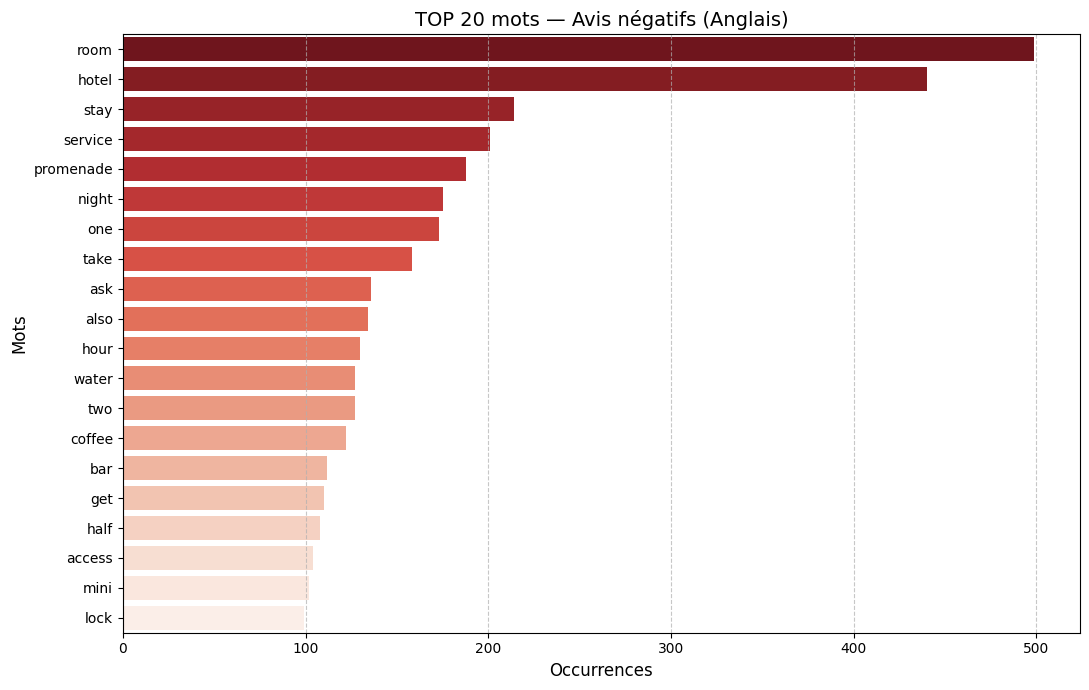

In [34]:
plot_top_words(negative_en, 'TOP 20 mots — Avis négatifs (Anglais)', 'Reds_r')

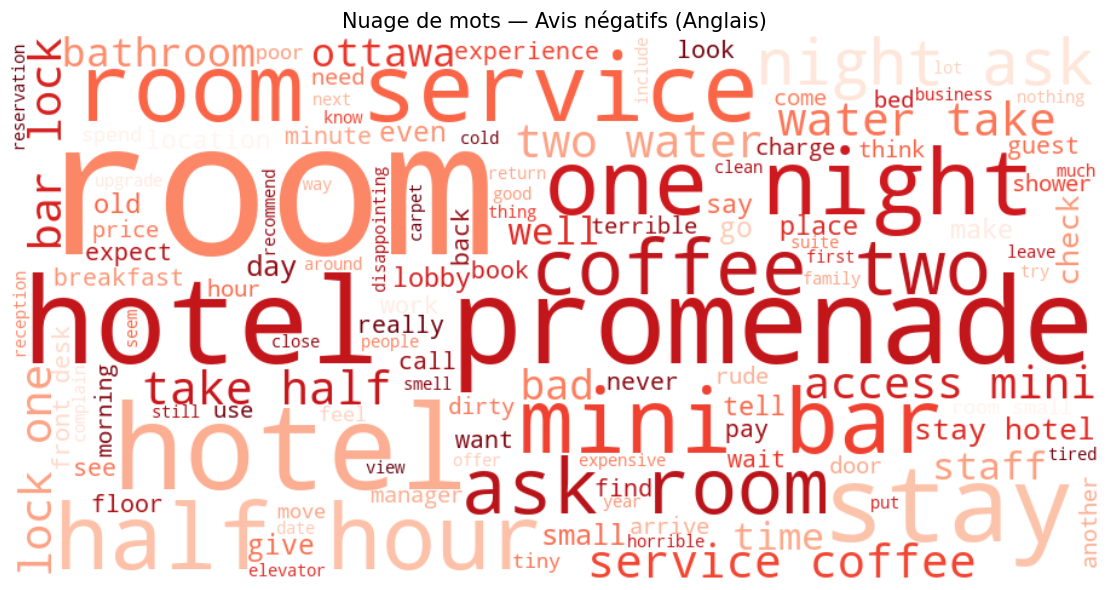

In [35]:
plot_wordcloud(negative_en, 'Nuage de mots — Avis négatifs (Anglais)', 'Reds')

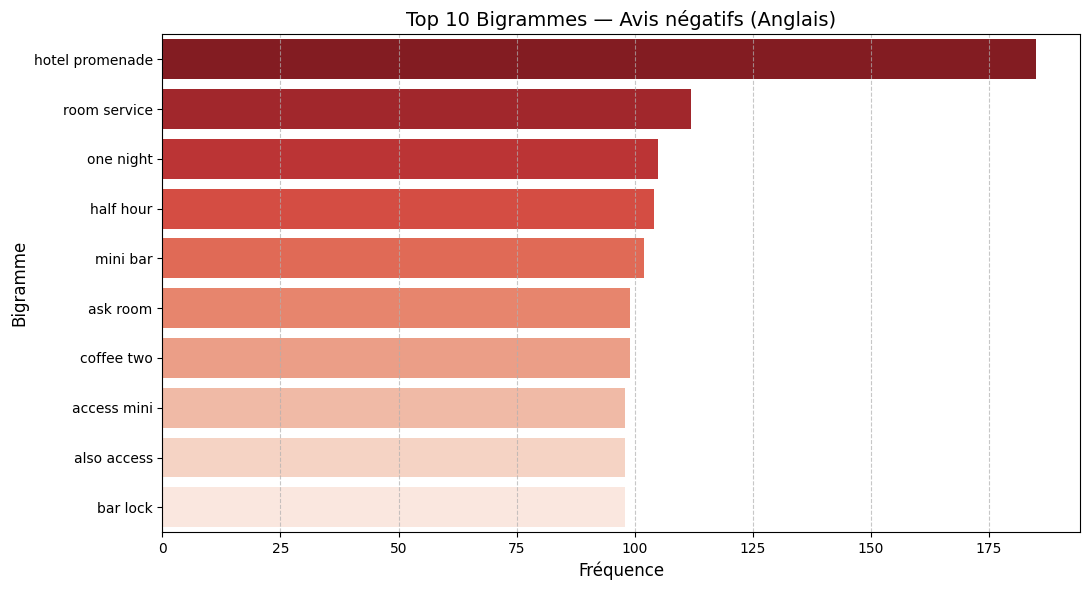

In [36]:
plot_bigrams  (negative_en, 'Top 10 Bigrammes — Avis négatifs (Anglais)', 'Reds_r')

In [37]:
run_lda       (negative_en, 'Avis négatifs (Anglais)')


=== Thèmes latents — Avis négatifs (Anglais) ===
Thème 1: worth, excellence, rank, fully, cockroach, severe, least, luxury, view, equipment
Thème 2: area, design, historic, nasty, charm, common, separate, establishment, lack, child
Thème 3: year, noisy, unless, dark, noise, hotel, unhelpful, expectation, stay, room
Thème 4: salt, somewhere, ugly, else, quick, odor, mold, consider, unless, staying
Thème 5: hotel, room, stay, promenade, get, service, small, staff, bad, would


Les anglophones se plaignent surtout de problèmes graves d'hygiène (cafards, moisissure, odeurs), d'un personnel peu serviable face aux plaintes,

### INSIGHTS — AVIS POSITIFS FRANÇAIS
On analyse séparément pour révéler les axes de satisfaction propres aux francophones, potentiellement différents des EN en raison d'attentes culturelles spécifiques

In [38]:
positive_fr = df_fr[df_fr['sentiment_lang'] == 'Positive'].copy()
print(f"\n── Avis positifs français : {len(positive_fr)} ──")


── Avis positifs français : 518 ──


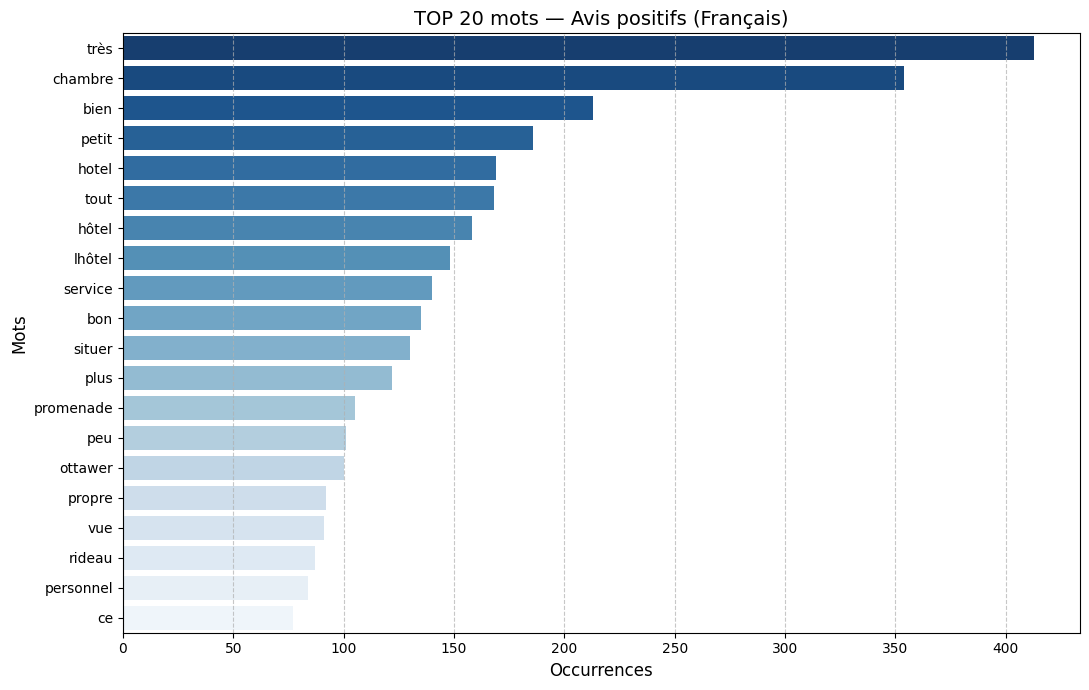

In [39]:
plot_top_words(positive_fr, 'TOP 20 mots — Avis positifs (Français)', 'Blues_r')

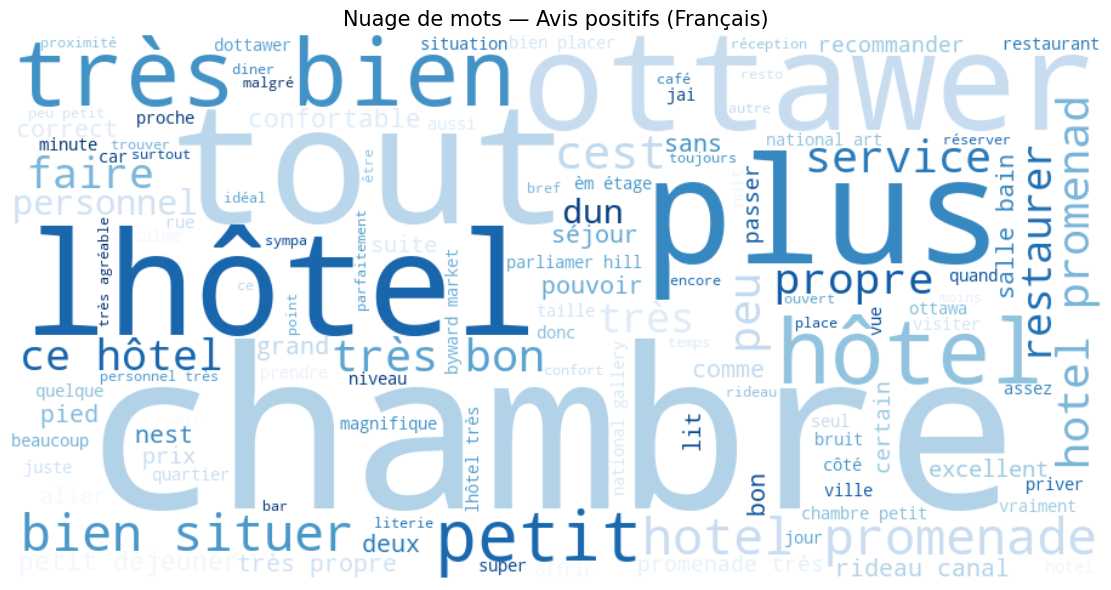

In [40]:
plot_wordcloud(positive_fr, 'Nuage de mots — Avis positifs (Français)', 'Blues')

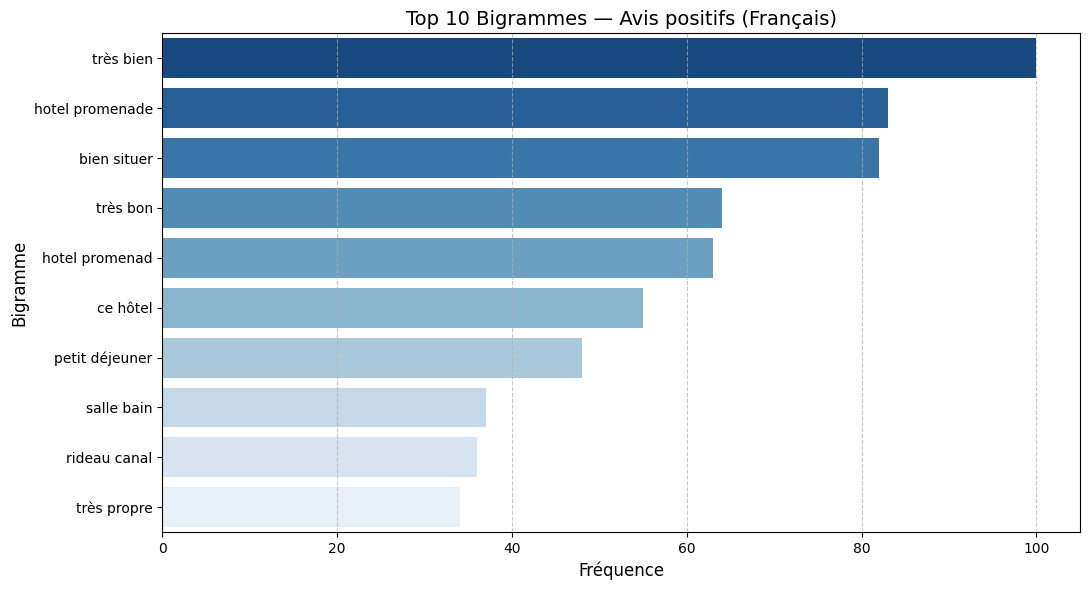

In [41]:
plot_bigrams  (positive_fr, 'Top 10 Bigrammes — Avis positifs (Français)', 'Blues_r')

In [42]:
run_lda       (positive_fr, 'Avis positifs (Français)')


=== Thèmes latents — Avis positifs (Français) ===
Thème 1: très, chambre, bien, petit, tout, hôtel, hotel, lhôtel, situer, bon
Thème 2: priver, chef, service, suite, complet, lexpérience, concevoir, organiser, personnaliser, dun
Thème 3: bar, élevé, proposer, séjour, lensembl, depuis, cocktail, créatier, prix, légèrement
Thème 4: inventif, collection, service, parfois, cuisine, raffiner, gastronomique, proposer, lent, dégustation
Thème 5: efficace, espace, commun, service, magnifiquement, malgré, promesse, menu, plus, élégamment


Les francophones satisfaits valorisent : le confort des chambres et la situation (thème 1), les suites et le service personnalisé (thème 2), l'offre bar/cocktails (thème 3), la cuisine gastronomique (thème 4) et les espaces communs (thème 5). Le champ lexical est raffiné les clients positifs francophones sont sensibles à l'expérience haut de gamme globale.

## INSIGHTS — AVIS NÉGATIFS FRANÇAIS
Segment prioritaire : taux d'insatisfaction ~5X supérieur aux anglophones. Les thèmes latents guident les actions correctives ciblées pour la clientèle francophone.

In [43]:
negative_fr = df_fr[df_fr['sentiment_lang'] == 'Negative'].copy()
print(f"\n── Avis négatifs français : {len(negative_fr)} ──")


── Avis négatifs français : 201 ──


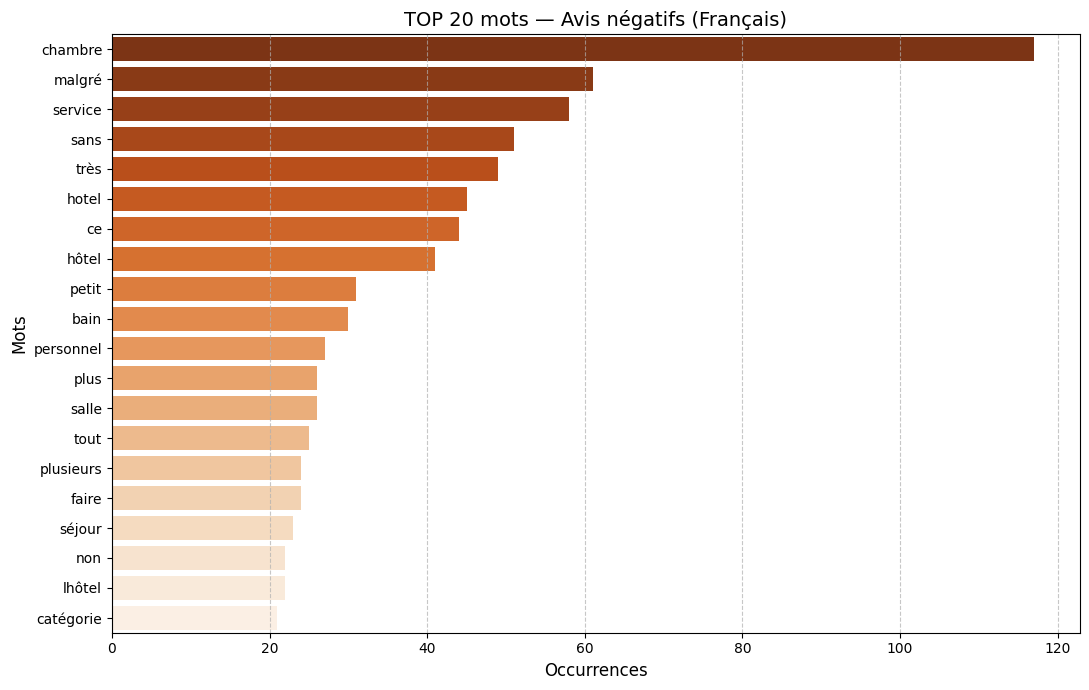

In [44]:
plot_top_words(negative_fr, 'TOP 20 mots — Avis négatifs (Français)', 'Oranges_r')

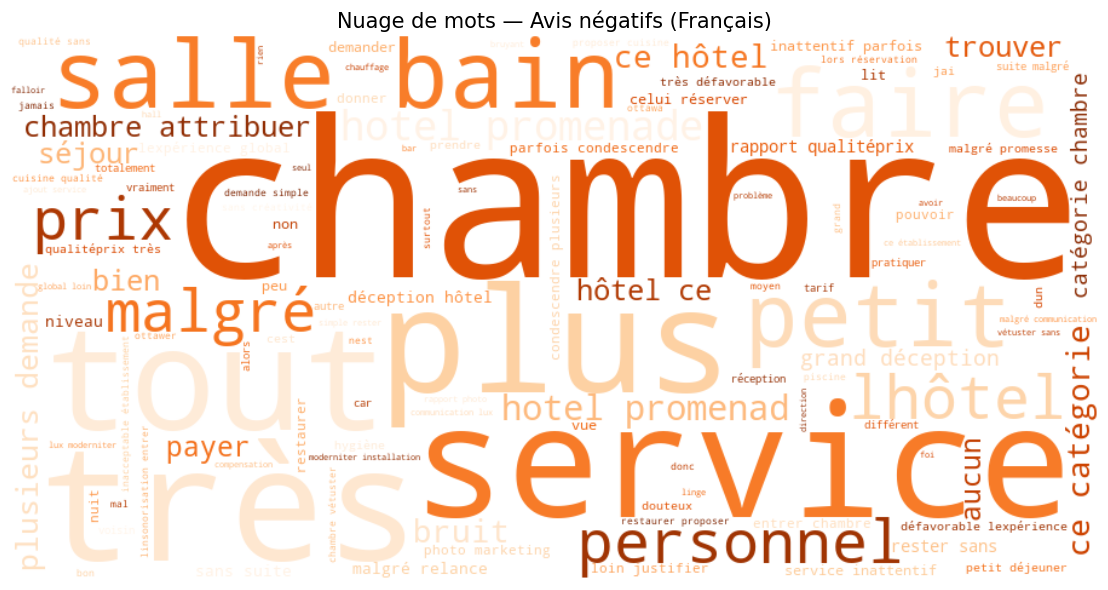

In [45]:
plot_wordcloud(negative_fr, 'Nuage de mots — Avis négatifs (Français)', 'Oranges')

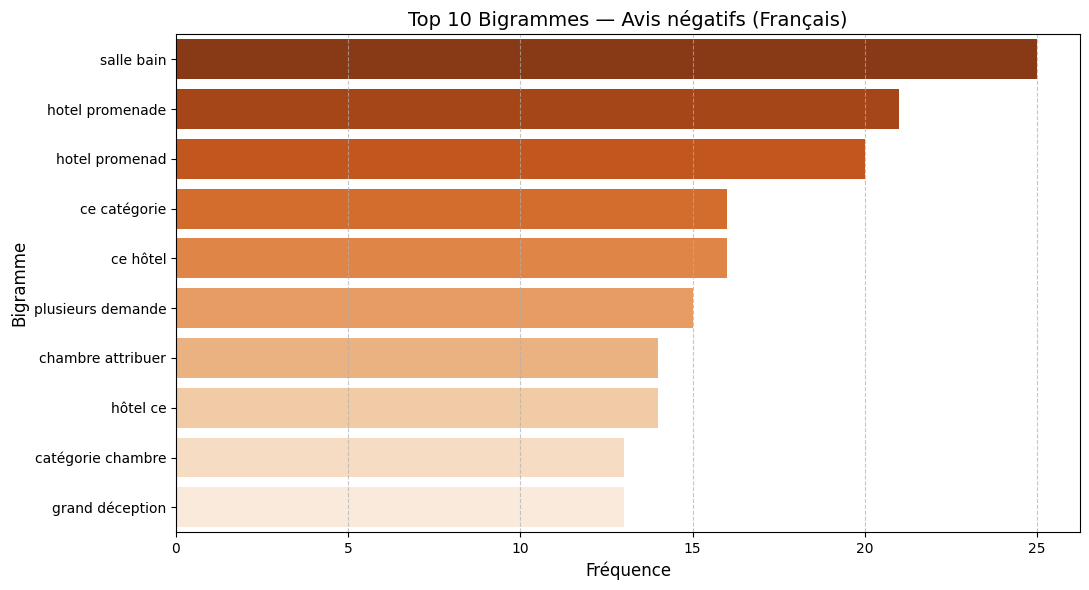

In [46]:
plot_bigrams  (negative_fr, 'Top 10 Bigrammes — Avis négatifs (Français)', 'Oranges_r')

In [47]:
run_lda       (negative_fr, 'Avis négatifs (Français)')


=== Thèmes latents — Avis négatifs (Français) ===
Thème 1: très, chambre, qualitéprix, loin, défavorable, rapport, justifier, hotel, global, lexpérience
Thème 2: hôtel, ce, catégorie, déception, attribuer, celui, grand, réserver, séjour, chambre
Thème 3: demande, malgré, plusieurs, rester, service, relance, suite, parfois, inattentif, condescendre
Thème 4: équipement, communication, sans, cuisine, créativité, marketing, qualité, vétuster, défectueux, restaurer
Thème 5: diamant, négliger, expérience, désastreux, malgré, infrastructure, mérite, aucunement, classemer, approximatif


Ces cinq thèmes montrent que les francophones sont nettement plus sensibles au standing perçu, au respect de la réservation et à la transparence tarifaire. C'est un signal fort pour adapter la communication et les processus quand la clientèle est francophone

## TABLEAU DE SYNTHÈSE GLOBAL — FR vs EN

  Langue  Total  Positifs % Positifs  Négatifs % Négatifs  Neutres % Neutres
Français    910       518      56.9%       201      22.1%      191     21.0%
 Anglais   5035      4441      88.2%       222       4.4%      372      7.4%


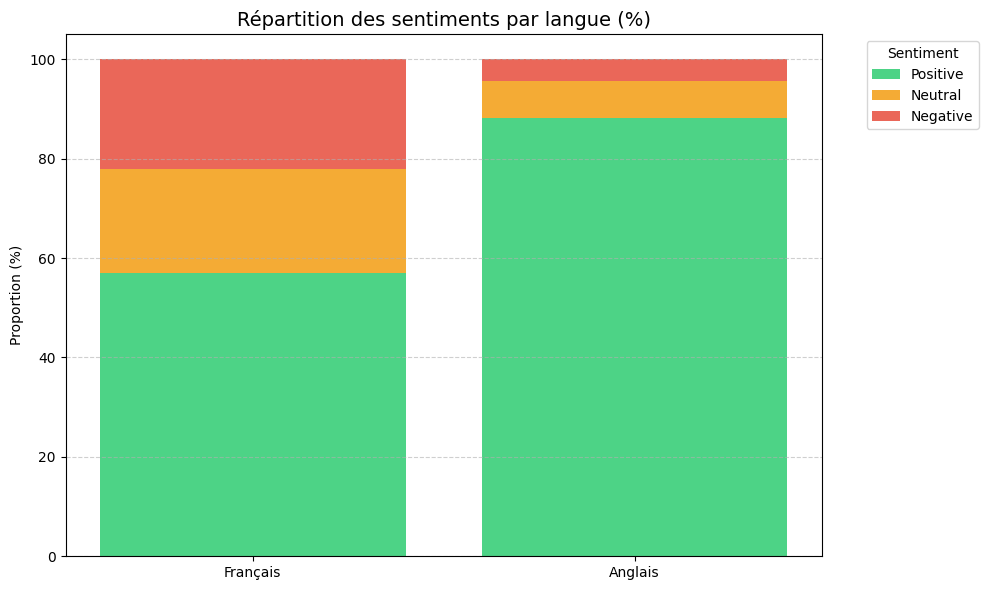

In [48]:
summary_data = []
for lang, ds in [('Français', df_fr), ('Anglais', df_en)]:
    counts = ds['sentiment_lang'].value_counts()
    total  = len(ds)
    summary_data.append({
        'Langue': lang, 'Total': total,
        'Positifs': counts.get('Positive',0), '% Positifs': f"{counts.get('Positive',0)/total*100:.1f}%",
        'Négatifs': counts.get('Negative',0), '% Négatifs': f"{counts.get('Negative',0)/total*100:.1f}%",
        'Neutres' : counts.get('Neutral', 0), '% Neutres' : f"{counts.get('Neutral', 0)/total*100:.1f}%",
    })
print(pd.DataFrame(summary_data).to_string(index=False))

# Stacked bar
fig, ax = plt.subplots(figsize=(10, 6))
bottoms = [0, 0]
for sent, color in [('Positive','#2ecc71'),('Neutral','#f39c12'),('Negative','#e74c3c')]:
    vals = [ds['sentiment_lang'].value_counts().get(sent,0)/len(ds)*100 for ds in [df_fr, df_en]]
    ax.bar(['Français','Anglais'], vals, bottom=bottoms, color=color, label=sent, alpha=0.85)
    bottoms = [b+v for b,v in zip(bottoms, vals)]
ax.set_title('Répartition des sentiments par langue (%)', fontsize=14)
ax.set_ylabel('Proportion (%)'); ax.legend(title='Sentiment', bbox_to_anchor=(1.05,1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()